# 1 — Exploratory analysis

**Purpose:** understand the data before modelling anything, and establish the facts that
justify the design choices made later in the pipeline.

Every modelling decision in this project traces back to something measured here. The point of
this notebook is that those decisions are *derived*, not assumed.

## Steps

| Step | What it does | What it decides |
|---|---|---|
| 1 | Load the cache and confirm the patient-level split | That train/val/test never share a patient |
| 2 | Measure class balance | Whether accuracy is a usable metric (it is not) |
| 3 | Measure tumour volume spread | Whether to report a mean or a distribution |
| 4 | Compare the four MRI modalities | Why normalisation is per-modality |
| 5 | Inspect one patient visually | Sanity check that labels align with anatomy |
| 6 | Summarise the implications | The design choices these facts force |

**Prerequisite:** `python scripts/build_cache.py --n 300` must have been run.

---
## Step 1 — Load the cache and confirm the split

The split is by **patient**, computed deterministically from a fixed seed. This matters more
than it might appear: two `128³` patches taken from the same brain are near-duplicates, so
splitting at the patch or slice level would put near-copies of test data into training and
inflate every score that follows.

The split is computed once, here and in training, from the same function — so it cannot drift.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CACHE_DIR, MODALITIES
from src.data import cached_case_ids, load_case, split_cases

case_ids = cached_case_ids()
train_ids, val_ids, test_ids = split_cases()

print(f"cached patients : {len(case_ids)}")
print(f"train           : {len(train_ids)}")
print(f"validation      : {len(val_ids)}")
print(f"test            : {len(test_ids)}")

overlap = (set(train_ids) & set(test_ids)) | (set(train_ids) & set(val_ids)) | (set(val_ids) & set(test_ids))
print(f"\npatient overlap between splits: {len(overlap)}  <- must be 0")

cached patients : 300
train           : 210
validation      : 45
test            : 45

patient overlap between splits: 0  <- must be 0


---
## Step 2 — Measure class balance

This is the single most consequential measurement in the notebook.

If tumour occupies a small fraction of voxels, then a model that predicts *nothing at all*
scores extremely well on accuracy. That makes accuracy worse than useless — it actively
rewards the degenerate solution. The number below is why the loss function is Dice+CE and
why patch sampling is biased toward tumour.

In [2]:
sample = case_ids[:40]
counts = np.zeros(4, dtype=np.int64)

for cid in sample:
    _, seg = load_case(cid)
    counts += np.bincount(seg.ravel(), minlength=4)

frac = counts / counts.sum()
labels = ["0  background", "1  necrotic core", "2  oedema", "3  enhancing tumour"]

print(f"measured over {len(sample)} patients (after cropping to the brain)\n")
for name, f in zip(labels, frac):
    print(f"  {name:<22}{f*100:7.3f} %")

tumour = frac[1:].sum()
print(f"\n  tumour total          {tumour*100:7.3f} %")
print(f"\nA model predicting all-background would score {(1-tumour)*100:.1f}% voxel accuracy")
print("while being clinically worthless. This is why accuracy is never reported here.")

measured over 40 patients (after cropping to the brain)

  0  background          97.810 %
  1  necrotic core        0.276 %
  2  oedema               1.425 %
  3  enhancing tumour     0.489 %

  tumour total            2.190 %

A model predicting all-background would score 97.8% voxel accuracy
while being clinically worthless. This is why accuracy is never reported here.


---
## Step 3 — Measure tumour volume spread

Tumour size varies by an order of magnitude across patients. That has a direct consequence
for reporting: a single mean Dice hides the fact that small tumours are much harder than
large ones, and that the same model can be excellent on one patient and poor on the next.

This is why every result in this project is reported as a distribution, not a point estimate.

,WT_cm3,TC_cm3,ET_cm3
count,40.0,40.0,40.0
mean,82.5,28.8,18.4
std,52.5,25.1,12.0
min,9.2,0.3,0.3
25%,37.3,13.8,10.0
50%,79.5,23.3,15.9
75%,120.1,36.2,26.1
max,197.2,115.8,47.2


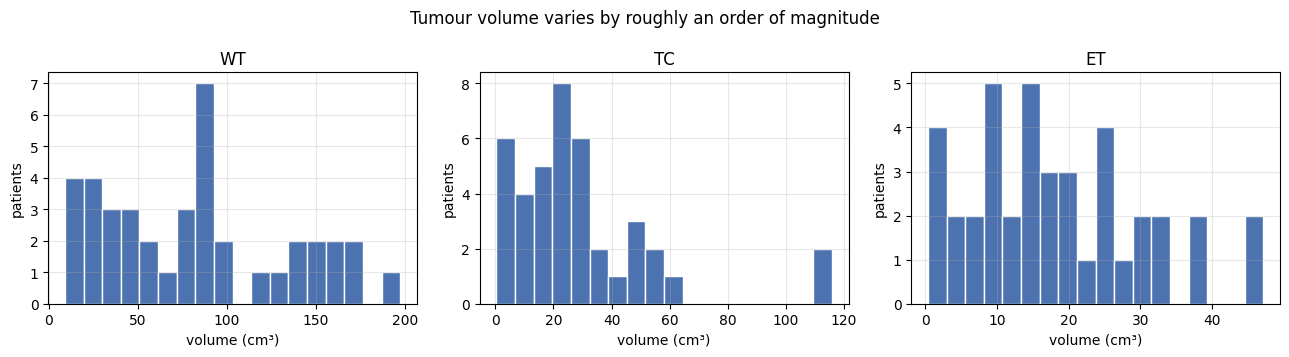

whole tumour ranges 9–197 cm³ (21x)


In [3]:
vols = []
for cid in sample:
    _, seg = load_case(cid)
    vols.append({
        "case_id": cid,
        "WT_cm3": (seg > 0).sum() / 1000,
        "TC_cm3": np.isin(seg, [1, 3]).sum() / 1000,
        "ET_cm3": (seg == 3).sum() / 1000,
    })
vols = pd.DataFrame(vols)

display(vols[["WT_cm3", "TC_cm3", "ET_cm3"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, region in zip(axes, ["WT", "TC", "ET"]):
    ax.hist(vols[f"{region}_cm3"], bins=18, color="#4c72b0", edgecolor="white")
    ax.set(xlabel="volume (cm³)", ylabel="patients", title=region)
    ax.grid(alpha=0.3)
fig.suptitle("Tumour volume varies by roughly an order of magnitude")
fig.tight_layout()
plt.show()

print(f"whole tumour ranges {vols.WT_cm3.min():.0f}–{vols.WT_cm3.max():.0f} cm³ "
      f"({vols.WT_cm3.max()/vols.WT_cm3.min():.0f}x)")

---
## Step 4 — Compare the four MRI modalities

MRI intensity has **no absolute scale**. Unlike CT (where Hounsfield units mean something
fixed), the raw numbers depend on scanner, sequence parameters and calibration. Two scans of
the same tissue on different machines can differ by a large multiplicative factor.

The left panel shows raw intensities — note the different ranges per modality. The right
panel shows the same data after per-modality z-scoring over brain voxels only, which is what
makes patients comparable to each other and to the model.

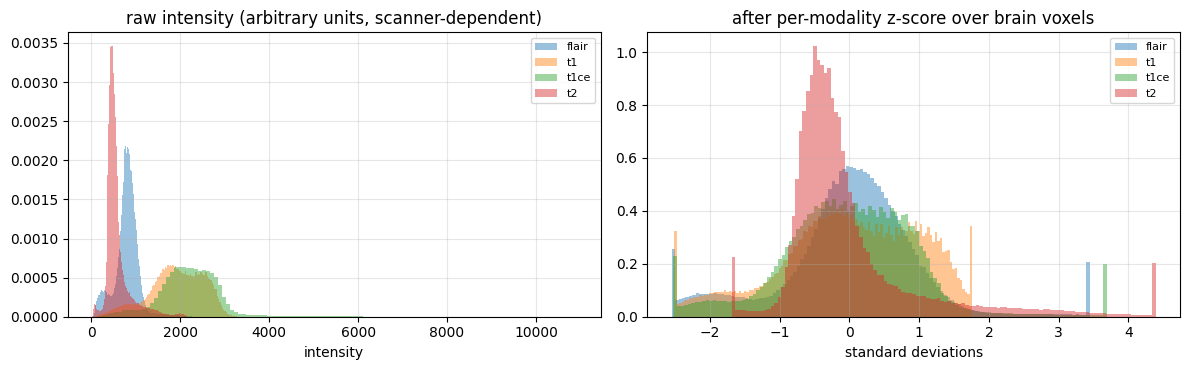

raw value ranges per modality:
  flair  min     26.0   max   2636.0   mean    791.5
  t1     min     56.0   max   3476.0   mean   1903.2
  t1ce   min     47.0   max  10912.0   mean   2209.3
  t2     min     17.0   max   2308.0   mean    583.8


In [4]:
from src.preprocessing import normalize_volume

img, seg = load_case(case_ids[0])
norm = normalize_volume(img, method="zscore")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for i, m in enumerate(MODALITIES):
    axes[0].hist(img[i][img[i] > 0].ravel(), bins=120, alpha=0.45, label=m, density=True)
    axes[1].hist(norm[i][norm[i] != 0].ravel(), bins=120, alpha=0.45, label=m, density=True)

axes[0].set(title="raw intensity (arbitrary units, scanner-dependent)", xlabel="intensity")
axes[1].set(title="after per-modality z-score over brain voxels", xlabel="standard deviations")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("raw value ranges per modality:")
for i, m in enumerate(MODALITIES):
    v = img[i][img[i] > 0]
    print(f"  {m:<6} min {v.min():8.1f}   max {v.max():8.1f}   mean {v.mean():8.1f}")

---
## Step 5 — Inspect one patient

A numerical check is not a substitute for looking at the data. This confirms that labels
align with visible anatomy and that the four modalities show what they are supposed to.

The slice shown is the one containing the most tumour. Note how the enhancing tumour
(yellow) is visible on **T1ce** specifically — that is the contrast agent doing its job, and
it is the reason the model needs all four inputs rather than FLAIR alone.

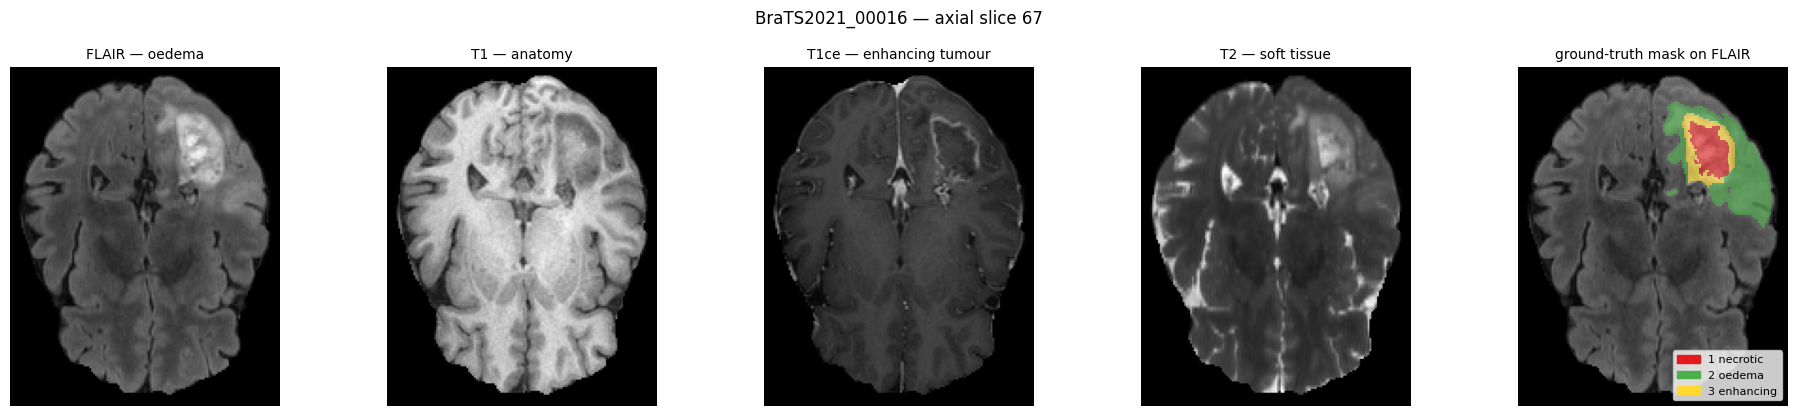

In [5]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

z = int((seg > 0).sum(axis=(0, 1)).argmax())
cmap = ListedColormap(["#e41a1c", "#4daf4a", "#ffd92f"])
titles = {"flair": "FLAIR — oedema", "t1": "T1 — anatomy",
          "t1ce": "T1ce — enhancing tumour", "t2": "T2 — soft tissue"}

fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))
for ax, i, m in zip(axes, range(4), MODALITIES):
    ax.imshow(np.rot90(img[i][:, :, z]), cmap="gray")
    ax.set_title(titles[m], fontsize=10)
    ax.axis("off")

axes[4].imshow(np.rot90(img[0][:, :, z]), cmap="gray")
axes[4].imshow(np.ma.masked_equal(np.rot90(seg[:, :, z]), 0), cmap=cmap,
               vmin=1, vmax=3, alpha=0.6, interpolation="nearest")
axes[4].set_title("ground-truth mask on FLAIR", fontsize=10)
axes[4].axis("off")
axes[4].legend(handles=[Patch(color="#e41a1c", label="1 necrotic"),
                        Patch(color="#4daf4a", label="2 oedema"),
                        Patch(color="#ffd92f", label="3 enhancing")],
               loc="lower right", fontsize=8)

fig.suptitle(f"{case_ids[0]} — axial slice {z}")
fig.tight_layout()
plt.show()

---
## Step 6 — What these measurements force

Each design decision in the pipeline traces to a measurement above:

| Measured fact | Consequence |
|---|---|
| Tumour is ~2% of voxels (Step 2) | Accuracy is unusable → **Dice+CE loss**, and **50% of patches centred on tumour** |
| Volume varies ~8x across patients (Step 3) | Report **distributions and per-patient spread**, not just means |
| Intensity scales differ per modality (Step 4) | **Per-modality z-scoring** over brain voxels, background pinned to 0 |
| Enhancing tumour visible only on T1ce (Step 5) | All **four modalities as input channels**, not FLAIR alone |
| Patches from one brain are near-duplicates | **Patient-level splits** — never by slice or patch |

None of these are defaults carried over from a tutorial. They are responses to what the data
turned out to be.

**Next:** `02_pipeline_walkthrough.ipynb` runs one patient through every stage of the pipeline.